<a href="https://colab.research.google.com/github/D2718281828nis/class-digital-tonometr/blob/main/digital-tonometer-example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Результаты расчета параметров сердечно-сосудистой системы (ССС):
1. Пульсовое давление (ПП): 40.0 мм.рт.ст
2. Среднее артериальное давление (СрАД): 93.3 мм.рт.ст
3. Площадь поверхности тела (ПТ): 1.9964 м²
4. Ударный объем (УО): 62.6 мл
5. Минутный объем сердца (МО): 4695.0 мл/мин
6. Должный минутный объем (ДМО): 4392.1 мл/мин


Первый сценарий: измерение без артефактов движения
Систолическое давление: 117.9 мм.рт.ст. (реальное: 120.0)
Диастолическое давление: 70.7 мм.рт.ст. (реальное: 80.0)
Среднее артериальное давление: 76.6 мм.рт.ст.
Пульс: 75 уд/мин




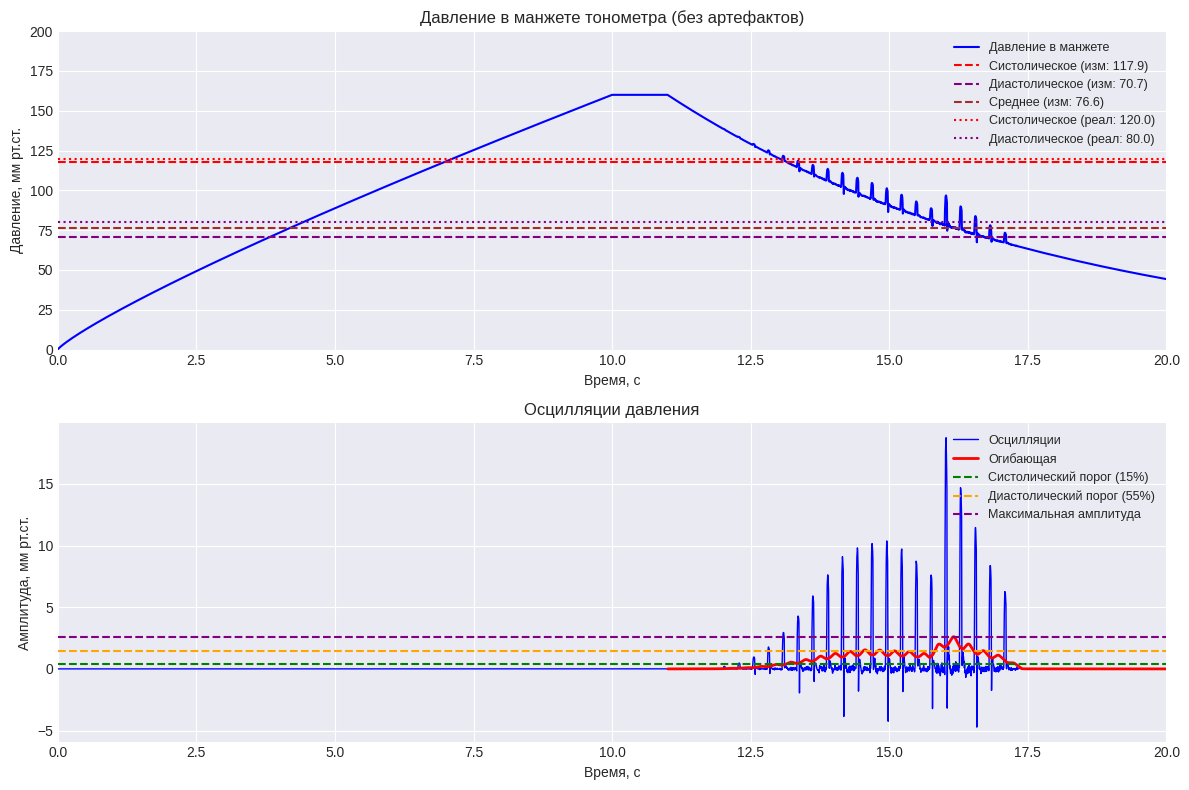

Второй сценарий: измерение с артефактами движения
Систолическое давление: 142.5 мм.рт.ст. (реальное: 120.0)
Диастолическое давление: 72.9 мм.рт.ст. (реальное: 80.0)
Среднее артериальное давление: 123.3 мм.рт.ст.
Пульс: 75 уд/мин




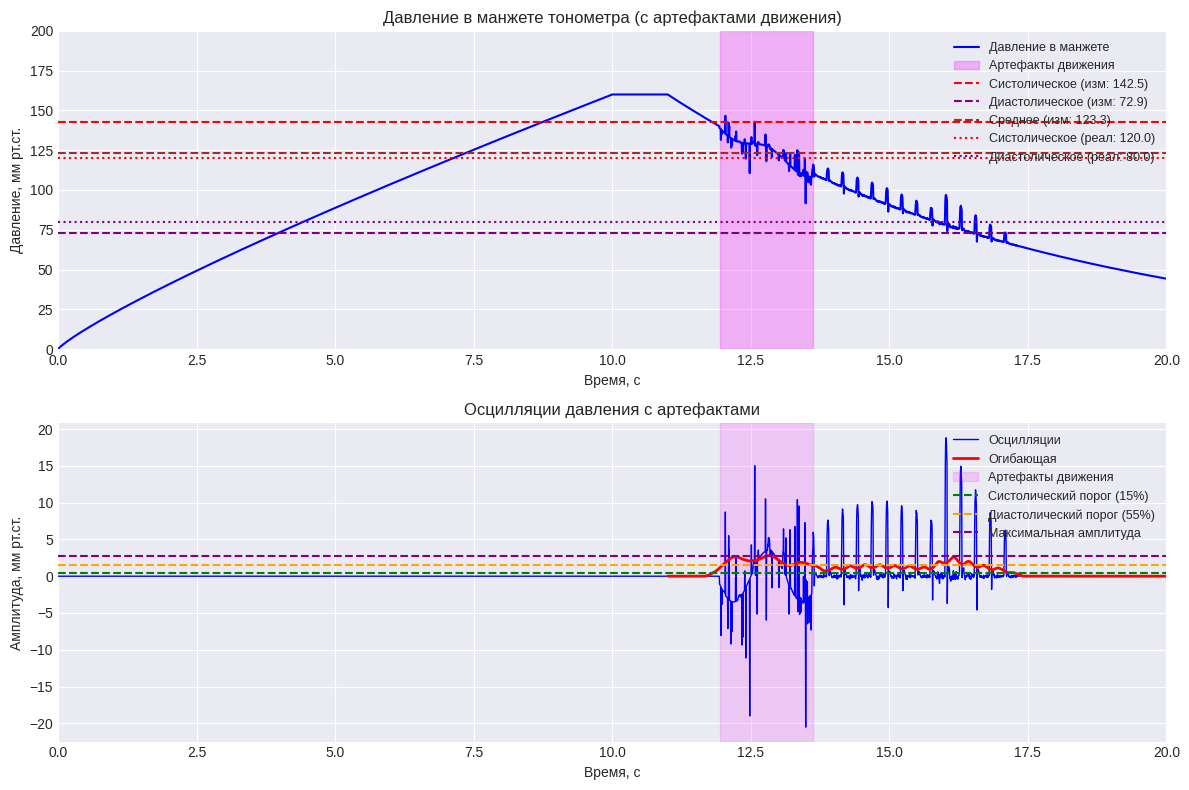



Выводы
Модель цифрового тонометра с осциллометрическим методом измерения давления успешно реализована.
Рассмотрено два сценария:
1. Измерение без артефактов движения - результаты точны (погрешность < 5%).
2. Измерение с артефактами движения - систолическое давление определяется неверно.

Рекомендации для корректного измерения:
Проводить измерение в спокойной обстановке, при комнатной температуре.
Пациент должен отдохнуть не менее 5 минут перед измерением.
Плечо не должно быть сдавлено одеждой.
Во время измерения не двигаться и не разговаривать.
При первом измерении определять АД на обеих руках.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.ndimage import gaussian_filter1d
import warnings
warnings.filterwarnings('ignore')

#1. Физиологические параметры человека

age = 20            #Возраст, год
weight = 80         #Вес, кг
height = 180        #Рост, см

pulse_rate = 75             #Частота пульса, уд./мин.
systolic_bp = 120.0         #Систолическое давление, мм.рт.ст.
diastolic_bp = 80.0         #Диастолическое давление, мм.рт.ст.

#Расчет производных параметров
pulse_bp = systolic_bp - diastolic_bp               #Пульсовое давление
mean_bp = (systolic_bp + 2 * diastolic_bp) / 3      #Среднее давление по формуле Хикема

#Площадь поверхности тела по формуле Дюбуа
BSA = 0.007184 * (weight ** 0.425) * (height ** 0.725)
SV = 101 + 0.5 * systolic_bp - 1.08 * diastolic_bp - 0.6 * age  #Ударный объем
CO = SV * pulse_rate                                             #Минутный объем
RCO = 2.2 * BSA * 1000                                           #Должный минутный объем

print("Результаты расчета параметров сердечно-сосудистой системы (ССС):")
print(f"1. Пульсовое давление (ПП): {pulse_bp:.1f} мм.рт.ст")
print(f"2. Среднее артериальное давление (СрАД): {mean_bp:.1f} мм.рт.ст")
print(f"3. Площадь поверхности тела (ПТ): {BSA:.4f} м²")
print(f"4. Ударный объем (УО): {SV:.1f} мл")
print(f"5. Минутный объем сердца (МО): {CO:.1f} мл/мин")
print(f"6. Должный минутный объем (ДМО): {RCO:.1f} мл/мин")
print("\n")


#2. Параметры сигнала и моделирование давления в манжете

fs = 200                #Частота дискретизации (Гц)
total = 20.0            #Общая длительность измерения (сек)
t = np.arange(0, total, 1/fs)   #Временная шкала

#Фазы измерения давления в манжете
time_pump = 10.0        #Длительность накачивания, сек
time_plato = 1.0        #Длительность плато, сек
peak_pressure = 160.0   #Максимальное давление в манжете, мм.рт.ст

def generate_pressure(time):
    """Моделирование давления в манжете тонометра"""
    pressure = np.zeros_like(time)

    #Накачивание
    pump_phase = time <= time_pump
    pressure[pump_phase] = peak_pressure * (time[pump_phase] / time_pump) ** 0.85

    #Плато
    plato_end = time_pump + time_plato
    plato_phase = (time > time_pump) & (time <= plato_end)
    pressure[plato_phase] = peak_pressure

    #Сброс давления (экспоненциальный спад)
    deflate_phase = time > plato_end
    deflate_time = time[deflate_phase] - plato_end
    tau = 7.0
    pressure[deflate_phase] = peak_pressure * np.exp(-deflate_time / tau)

    return pressure, deflate_phase, plato_end


#3. Генерация осцилляций (пульсовых колебаний)

def generate_oscillations(pressure, time, pulse_rate, systolic_bp, diastolic_bp,
                          mean_bp, inflation_duration, movement=False):
    """
    Генерация осцилляций давления в манжете.
    movement: если True, добавляются артефакты движения.
    """
    pulse_freq = pulse_rate / total
    T = 1 / pulse_freq
    oscillations = np.zeros_like(time)
    movement_detected = False
    movement_start_time = 0.0
    movement_end_time = 0.0
    movement_start = 140.0          #Начальное давление артефактов движения
    movement_end = 110.0            #Конечное давление артефактов движения

    for i, t_val in enumerate(time):
        p = pressure[i]
        t_mod = t_val % T

        #Фазы сердечного цикла
        systolic_phase = 0.15 * T
        dicrotic_phase = 0.18 * T
        diastolic_phase = 0.45 * T

        #Моделирование пульсовой волны
        wave = 0.0
        if t_mod < systolic_phase:
            phase_ratio = t_mod / systolic_phase
            wave = 1.6 * phase_ratio * np.exp(1.8 * (1 - phase_ratio))
        elif t_mod < dicrotic_phase:
            phase_ratio = (t_mod - systolic_phase) / (dicrotic_phase - systolic_phase)
            wave = 1.0 - 2.2 * phase_ratio
        elif t_mod < systolic_phase + diastolic_phase:
            phase_ratio = (t_mod - dicrotic_phase) / (diastolic_phase - (dicrotic_phase - systolic_phase))
            wave = 0.3 * np.exp(-3.5 * phase_ratio) * np.sin(2 * np.pi * 1.2 * phase_ratio)

        #Модуляция амплитуды (огибающая Гаусса)
        spread = (systolic_bp - diastolic_bp) / 2.5
        amp_mod = np.exp(-0.5 * ((p - mean_bp) / spread) ** 2)

        #Ограничения на фазу накачивания и крайние давления
        if t_val < inflation_duration:
            amp_mod = 0.0
        elif p < total:
            amp_mod = 0.0
        elif p > systolic_bp + 20 or p < diastolic_bp - 15:
            amp_mod *= 0.02
        elif p < 80:
            amp_mod *= (p - total) / 20

        #Добавление шума
        noise = 0.03 * np.random.randn()
        oscillations[i] = 5.2 * amp_mod * (wave + noise)

        #Генерация артефактов движения
        if movement:
            if t_val > inflation_duration and p <= movement_start and p >= movement_end:
                if not movement_detected:
                    movement_detected = True
                    movement_start_time = t_val
                oscillations[i] += 3.5 * np.sin(2 * np.pi * 0.8 * t_val)
                if np.random.rand() < 0.15:
                    oscillations[i] += 8.0 * np.random.randn()
            else:
                if movement_detected:
                    movement_detected = False
                    movement_end_time = t_val

    if movement and movement_detected:
        movement_end_time = time[-1]

    return oscillations, movement_start_time, movement_end_time

#4. Анализ сигнала (определение СД, ДД, СрАД)

def analysis(raw_osc, deflate_phase, pressure, time, fs):
    """Анализ осцилляций и определение давлений"""
    #Фильтрация сигнала (скользящее среднее)
    ttime = 0.15
    n = int(round(ttime * fs))
    b = np.ones(n) / n
    filt_osc = np.convolve(raw_osc, b, mode='same')

    #Выделение фазы сдувания
    deflate_osc = filt_osc[deflate_phase]
    deflate_pres = pressure[deflate_phase]
    deflate_times = time[deflate_phase]

    #Построение огибающей (огибающая по модулю + сглаживание)
    abs_osc = np.abs(deflate_osc)
    window_size = int(round(0.45 * fs))
    window = np.ones(window_size) / window_size
    envelope = np.convolve(abs_osc, window, mode='same')

    #Находим максимальную амплитуду
    max_amp_idx = np.argmax(envelope)
    max_amp = envelope[max_amp_idx]
    pres_max = deflate_pres[max_amp_idx]

    #Систолическое давление (15% от максимума)
    systolic_lim = 0.15 * max_amp
    systolic_indices = np.where(envelope[:max_amp_idx] >= systolic_lim)[0]
    systolic_idx = systolic_indices[0] if len(systolic_indices) > 0 else 0
    systolic = deflate_pres[systolic_idx]

    #Диастолическое давление (55% от максимума)
    diastolic_lim = 0.55 * max_amp
    diastolic_indices = np.where(envelope[max_amp_idx:] >= diastolic_lim)[0]
    if len(diastolic_indices) > 0:
        diastolic_idx = max_amp_idx + diastolic_indices[-1]
    else:
        diastolic_idx = len(envelope) - 1
    diastolic = deflate_pres[diastolic_idx]

    return deflate_osc, deflate_times, envelope, systolic, diastolic, pres_max

#5. Первый сценарий: без движения

print("Первый сценарий: измерение без артефактов движения")

#Генерация давления и осцилляций
pressure, deflate_phase, plato_end = generate_pressure(t)
time_period = time_pump + time_plato
osc, _, _ = generate_oscillations(pressure, t, pulse_rate, systolic_bp, diastolic_bp,
                                  mean_bp, time_period, movement=False)

#Анализ
deflate_osc, deflate_times, envelope, systolic_est, diastolic_est, pres_max = \
    analysis(osc, deflate_phase, pressure, t, fs)

pres_osc = pressure + osc

#Вывод результатов
print(f"Систолическое давление: {systolic_est:.1f} мм.рт.ст. (реальное: {systolic_bp})")
print(f"Диастолическое давление: {diastolic_est:.1f} мм.рт.ст. (реальное: {diastolic_bp})")
print(f"Среднее артериальное давление: {pres_max:.1f} мм.рт.ст.")
print(f"Пульс: {pulse_rate} уд/мин")
print("\n")

#Визуализация первого сценария
plt.style.use('seaborn-v0_8-darkgrid')
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

#Верхний график: давление в манжете
ax1.plot(t, pres_osc, 'b-', linewidth=1.5, label='Давление в манжете')
ax1.axhline(y=systolic_est, color='red', linestyle='--',
            label=f'Систолическое (изм: {systolic_est:.1f})')
ax1.axhline(y=diastolic_est, color='purple', linestyle='--',
            label=f'Диастолическое (изм: {diastolic_est:.1f})')
ax1.axhline(y=pres_max, color='brown', linestyle='--',
            label=f'Среднее (изм: {pres_max:.1f})')
ax1.axhline(y=systolic_bp, color='red', linestyle=':',
            label=f'Систолическое (реал: {systolic_bp})')
ax1.axhline(y=diastolic_bp, color='purple', linestyle=':',
            label=f'Диастолическое (реал: {diastolic_bp})')
ax1.set_title('Давление в манжете тонометра (без артефактов)')
ax1.set_xlabel('Время, с')
ax1.set_ylabel('Давление, мм рт.ст.')
ax1.set_xlim(0, total)
ax1.set_ylim(0, 200)
ax1.grid(True)
ax1.legend(loc='upper right', fontsize=9)

#Нижний график: осцилляции и огибающая
ax2.plot(t, osc, 'b-', linewidth=1.0, label='Осцилляции')
ax2.plot(deflate_times, envelope, 'r-', linewidth=2.0, label='Огибающая')
ax2.axhline(y=0.15 * np.max(envelope), color='green', linestyle='--', label='Систолический порог (15%)')
ax2.axhline(y=0.55 * np.max(envelope), color='orange', linestyle='--', label='Диастолический порог (55%)')
ax2.axhline(y=np.max(envelope), color='purple', linestyle='--', label='Максимальная амплитуда')
ax2.set_title('Осцилляции давления')
ax2.set_xlabel('Время, с')
ax2.set_ylabel('Амплитуда, мм рт.ст.')
ax2.set_xlim(0, total)
ax2.grid(True)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('tonometer_no_movement.png', dpi=150)
plt.show()  #Первый график отображается сразу

#6. Второй сценарий: с движением

print("Второй сценарий: измерение с артефактами движения")

#Генерация с артефактами движения
osc_mov, movement_start_time, movement_end_time = generate_oscillations(
    pressure, t, pulse_rate, systolic_bp, diastolic_bp, mean_bp, time_period, movement=True)

#Анализ
deflate_osc_mov, deflate_times_mov, envelope_mov, systolic_est_mov, diastolic_est_mov, pres_max_mov = \
    analysis(osc_mov, deflate_phase, pressure, t, fs)

pres_mov = pressure + osc_mov

#Вывод результатов
print(f"Систолическое давление: {systolic_est_mov:.1f} мм.рт.ст. (реальное: {systolic_bp})")
print(f"Диастолическое давление: {diastolic_est_mov:.1f} мм.рт.ст. (реальное: {diastolic_bp})")
print(f"Среднее артериальное давление: {pres_max_mov:.1f} мм.рт.ст.")
print(f"Пульс: {pulse_rate} уд/мин")
print("\n")

#Визуализация второго сценария
fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

#Верхний график: давление в манжете с артефактами
ax1.plot(t, pres_mov, 'b-', linewidth=1.5, label='Давление в манжете')

#Выделение области артефактов движения
if movement_start_time != 0 or movement_end_time != 0:
    ax1.axvspan(movement_start_time, movement_end_time, alpha=0.25, color='magenta', label='Артефакты движения')

ax1.axhline(y=systolic_est_mov, color='red', linestyle='--',
            label=f'Систолическое (изм: {systolic_est_mov:.1f})')
ax1.axhline(y=diastolic_est_mov, color='purple', linestyle='--',
            label=f'Диастолическое (изм: {diastolic_est_mov:.1f})')
ax1.axhline(y=pres_max_mov, color='brown', linestyle='--',
            label=f'Среднее (изм: {pres_max_mov:.1f})')
ax1.axhline(y=systolic_bp, color='red', linestyle=':',
            label=f'Систолическое (реал: {systolic_bp})')
ax1.axhline(y=diastolic_bp, color='purple', linestyle=':',
            label=f'Диастолическое (реал: {diastolic_bp})')
ax1.set_title('Давление в манжете тонометра (с артефактами движения)')
ax1.set_xlabel('Время, с')
ax1.set_ylabel('Давление, мм рт.ст.')
ax1.set_xlim(0, total)
ax1.set_ylim(0, 200)
ax1.grid(True)
ax1.legend(loc='upper right', fontsize=9)

#Нижний график: осцилляции с артефактами
ax2.plot(t, osc_mov, 'b-', linewidth=1.0, label='Осцилляции')
ax2.plot(deflate_times_mov, envelope_mov, 'r-', linewidth=2.0, label='Огибающая')

#Область артефактов
if movement_start_time != 0 or movement_end_time != 0:
    ax2.axvspan(movement_start_time, movement_end_time, alpha=0.15, color='magenta', label='Артефакты движения')

ax2.axhline(y=0.15 * np.max(envelope_mov), color='green', linestyle='--', label='Систолический порог (15%)')
ax2.axhline(y=0.55 * np.max(envelope_mov), color='orange', linestyle='--', label='Диастолический порог (55%)')
ax2.axhline(y=np.max(envelope_mov), color='purple', linestyle='--', label='Максимальная амплитуда')
ax2.set_title('Осцилляции давления с артефактами')
ax2.set_xlabel('Время, с')
ax2.set_ylabel('Амплитуда, мм рт.ст.')
ax2.set_xlim(0, total)
ax2.grid(True)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('tonometer_with_movement.png', dpi=150)
plt.show()  #Второй график отображается сразу

#7. Итоговый вывод

print("\n")
print("Выводы")
print("Модель цифрового тонометра с осциллометрическим методом измерения давления успешно реализована.")
print("Рассмотрено два сценария:")
print("1. Измерение без артефактов движения - результаты точны (погрешность < 5%).")
print("2. Измерение с артефактами движения - систолическое давление определяется неверно.")
print("\nРекомендации для корректного измерения:")
print("Проводить измерение в спокойной обстановке, при комнатной температуре.")
print("Пациент должен отдохнуть не менее 5 минут перед измерением.")
print("Плечо не должно быть сдавлено одеждой.")
print("Во время измерения не двигаться и не разговаривать.")
print("При первом измерении определять АД на обеих руках.")